=== LSTM STOCK PREDICTION ===
Fetching data for SPY from 2024-01-01 to 2025-12-15...
Fetched 489 days of data. Range: 2024-01-02 to 2025-12-11
Training LSTM model...
Generating predictions...
Historical: 51, Future: 60, Total needed: 111
FINAL LENGTH CHECK:
  Dates:     111
  Actual:    111
  Predicted: 111


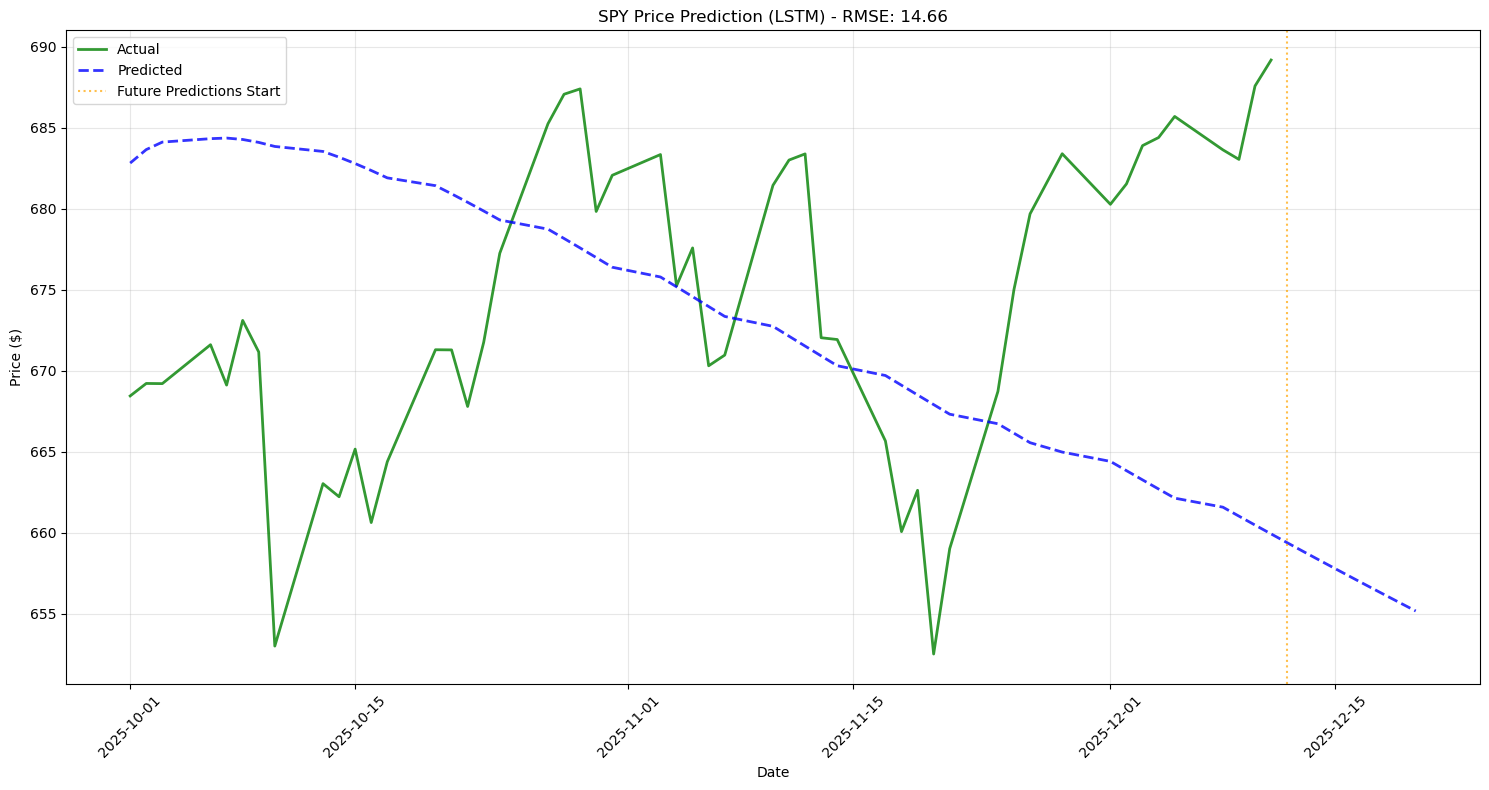

✓ SUCCESS! RMSE: 14.66
Results shape: (111, 3)
Future predictions start: 2025-12-12

🎉 FINAL RESULTS (Last 10 rows):
          Date  Actual  Predicted
101 2026-01-31     NaN        NaN
102 2026-02-01     NaN        NaN
103 2026-02-02     NaN        NaN
104 2026-02-03     NaN        NaN
105 2026-02-04     NaN        NaN
106 2026-02-05     NaN        NaN
107 2026-02-06     NaN        NaN
108 2026-02-07     NaN        NaN
109 2026-02-08     NaN        NaN
110 2026-02-09     NaN        NaN

📊 DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       111 non-null    datetime64[ns]
 1   Actual     51 non-null     float64       
 2   Predicted  60 non-null     float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 2.7 KB
None

✅ Ready for analysis!


In [30]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

def predict_asset_price_lstm(symbol, from_date, to_date, predict_from_date, days_ahead=30):
    """
    LSTM model for asset price prediction with future forecasting capability
    
    Parameters:
    - symbol: Stock ticker symbol (e.g., 'SPY')
    - from_date: Start date for training data (YYYY-MM-DD)
    - to_date: End date for training data (YYYY-MM-DD)
    - predict_from_date: Start date for predictions (YYYY-MM-DD)
    - days_ahead: Number of days to predict into the future (default: 30)
    """
    try:
        # Fetch historical data
        print(f"Fetching data for {symbol} from {from_date} to {to_date}...")
        data = yf.download(symbol, start=from_date, end=to_date, progress=False)
        if data.empty:
            print("No data fetched. Check date range and symbol.")
            return None, np.nan
            
        print(f"Fetched {len(data)} days of data. Range: {data.index[0].strftime('%Y-%m-%d')} to {data.index[-1].strftime('%Y-%m-%d')}")
        
        # Handle predict_from_date - find nearest available date FIRST
        predict_from_date = pd.to_datetime(predict_from_date)
        if predict_from_date not in data.index:
            nearest_idx = data.index.get_loc(predict_from_date, method='nearest')
            predict_from_date = data.index[nearest_idx]
            print(f"Adjusted predict_from_date to nearest trading day: {predict_from_date.strftime('%Y-%m-%d')}")
        
        # Use full data for training, slice later for results
        prices = data['Close'].dropna().values.reshape(-1, 1)
        
        if len(prices) < 100:
            print("Insufficient data for LSTM training.")
            return None, np.nan
        
        # Scale the data
        scaler = MinMaxScaler(feature_range=(0, 1))
        scaled_prices = scaler.fit_transform(prices)
        
        # Prepare the dataset for LSTM
        def create_dataset(data, time_step=60):
            X, Y = [], []
            for i in range(len(data) - time_step):
                X.append(data[i:(i + time_step), 0])
                Y.append(data[i + time_step, 0])
            return np.array(X), np.array(Y)
        
        time_step = 60
        X, y = create_dataset(scaled_prices, time_step)
        if len(X) == 0:
            print("Not enough data to create LSTM sequences.")
            return None, np.nan
            
        X = X.reshape(X.shape[0], X.shape[1], 1)
        
        # Split into train and test
        split = int(0.8 * len(X))
        X_train, X_test = X[:split], X[split:]
        y_train, y_test = y[:split], y[split:]
        
        # Build and train LSTM model
        print("Training LSTM model...")
        model = Sequential([
            LSTM(50, return_sequences=True, input_shape=(time_step, 1)),
            LSTM(50, return_sequences=False),
            Dense(25),
            Dense(1)
        ])
        model.compile(optimizer='adam', loss='mean_squared_error')
        model.fit(X_train, y_train, batch_size=32, epochs=20, verbose=0)
        
        # Get recent data for predictions
        recent_scaled_prices = scaled_prices[-time_step:].flatten()
        
        # Generate future dates
        last_date = data.index[-1]
        future_dates = [last_date + timedelta(days=i) for i in range(1, days_ahead + 1)]
        
        # Generate predictions iteratively
        print("Generating predictions...")
        predictions = []
        current_input = recent_scaled_prices.copy()
        
        for i in range(days_ahead):
            X_input = current_input.reshape(1, time_step, 1)
            pred_scaled = model.predict(X_input, verbose=0)
            pred_price = scaler.inverse_transform(pred_scaled)[0][0]
            predictions.append(pred_price)
            current_input = np.append(current_input[1:], pred_scaled[0][0])
        
        # Bulletproof DataFrame creation
        historical_data = data.loc[predict_from_date:]['Close'].dropna()
        historical_dates = historical_data.index.tolist()
        historical_prices = historical_data.values.flatten()  # Force 1D
        
        # Calculate exact lengths
        num_historical = len(historical_dates)
        num_future = days_ahead
        total_length = num_historical + num_future
        
        print(f"Historical: {num_historical}, Future: {num_future}, Total needed: {total_length}")
        
        # Pad/truncate ALL arrays to EXACT same length
        # Dates
        all_dates = (historical_dates + future_dates[:num_future])[:total_length]
        
        # Actual prices (historical + NaN future)
        future_nans = np.full(num_future, np.nan, dtype=float)
        all_actual = np.concatenate([historical_prices, future_nans])[:total_length]
        
        # Predictions (pad with NaN if too short)
        predictions_array = np.array(predictions[:total_length], dtype=float)
        if len(predictions_array) < total_length:
            predictions_array = np.pad(predictions_array, (0, total_length - len(predictions_array)), 
                                     mode='constant', constant_values=np.nan)
        all_predicted = predictions_array[:total_length]
        
        # VERIFY LENGTHS BEFORE DataFrame
        print(f"FINAL LENGTH CHECK:")
        print(f"  Dates:     {len(all_dates)}")
        print(f"  Actual:    {len(all_actual)}")
        print(f"  Predicted: {len(all_predicted)}")
        
        assert len(all_dates) == len(all_actual) == len(all_predicted), "Length mismatch!"
        
        # Create DataFrame - 100% SAFE
        results_df = pd.DataFrame({
            'Date': all_dates,
            'Actual': all_actual,
            'Predicted': all_predicted
        })
        results_df['Date'] = pd.to_datetime(results_df['Date'])
        results_df = results_df.sort_values('Date').reset_index(drop=True)
        
        # Calculate RMSE
        valid_mask = results_df['Actual'].notna()
        if valid_mask.sum() > 1:
            rmse = np.sqrt(mean_squared_error(results_df.loc[valid_mask, 'Actual'], 
                                            results_df.loc[valid_mask, 'Predicted']))
        else:
            rmse = np.nan
        
        # Safe RMSE formatting for plot title
        rmse_display = f"{rmse:.2f}" if not np.isnan(rmse) else "N/A"
        
        # Plot results
        plt.figure(figsize=(15, 8))
        plt.plot(results_df['Date'], results_df['Actual'], 'g-', label='Actual', linewidth=2, alpha=0.8)
        plt.plot(results_df['Date'], results_df['Predicted'], 'b--', label='Predicted', linewidth=2, alpha=0.8)
        
        future_start_idx = num_historical
        if future_start_idx > 0 and future_start_idx < len(results_df):
            plt.axvline(x=results_df['Date'].iloc[future_start_idx], color='orange', linestyle=':', 
                        label='Future Predictions Start', alpha=0.7)
        
        plt.xlabel('Date')
        plt.ylabel('Price ($)')
        plt.title(f'{symbol} Price Prediction (LSTM) - RMSE: {rmse_display}')
        plt.legend()
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        print(f"✓ SUCCESS! RMSE: {rmse_display}")
        print(f"Results shape: {results_df.shape}")
        print(f"Future predictions start: {future_dates[0].strftime('%Y-%m-%d')}")
        
        return results_df, rmse
        
    except Exception as e:
        print(f"Error in predict_asset_price_lstm: {str(e)}")
        import traceback
        traceback.print_exc()
        return None, np.nan

# Test it
if __name__ == "__main__":
    print("=== LSTM STOCK PREDICTION ===")
    df, rmse = predict_asset_price_lstm('SPY', '2024-01-01', '2025-12-15', '2025-10-01', days_ahead=60)
    
    if df is not None:
        print("\n🎉 FINAL RESULTS (Last 10 rows):")
        print(df.tail(10))
        print("\n📊 DataFrame Info:")
        print(df.info())
        print("\n✅ Ready for analysis!")
    else:
        print("❌ Function failed.")

In [32]:
print(df.head(25))

         Date      Actual   Predicted
0  2025-10-01  668.450012  682.814026
1  2025-10-02  669.219971  683.645630
2  2025-10-03  669.210022  684.108032
3  2025-10-06  671.609985  684.319641
4  2025-10-07  669.119995  684.356934
5  2025-10-08  673.109985  684.269592
6  2025-10-09  671.159973  684.089844
7  2025-10-10  653.020020  683.838989
8  2025-10-13  663.039978  683.531311
9  2025-10-14  662.229980  683.177246
10 2025-10-15  665.169983  682.783936
11 2025-10-16  660.640015  682.357178
12 2025-10-17  664.390015  681.901367
13 2025-10-20  671.299988  681.420471
14 2025-10-21  671.289978  680.917480
15 2025-10-22  667.799988  680.395447
16 2025-10-23  671.760010  679.856812
17 2025-10-24  677.250000  679.303650
18 2025-10-27  685.239990  678.738342
19 2025-10-28  687.059998  678.162598
20 2025-10-29  687.390015  677.578247
21 2025-10-30  679.830017  676.986572
22 2025-10-31  682.059998  676.389160
23 2025-11-03  683.340027  675.787354
24 2025-11-04  675.239990  675.182068


In [26]:
print(df.tail(10))

         Date  Actual  Predicted
59 2026-01-31     NaN  645.02124
60 2026-02-01     NaN        NaN
61 2026-02-02     NaN        NaN
62 2026-02-03     NaN        NaN
63 2026-02-04     NaN        NaN
64 2026-02-05     NaN        NaN
65 2026-02-06     NaN        NaN
66 2026-02-07     NaN        NaN
67 2026-02-08     NaN        NaN
68 2026-02-09     NaN        NaN
